# Laboratorio 9

- Edwin de Leon
- Gustavo Cruz
- Mathew Cordero


[Laboratorio 9](https://github.com/donmatthiuz/VIC/tree/lab9)

## Contexto

Usted ha sido contratado como Ingeniero de Visión por Computadora (CV Engineer) principal para la
convención de anime y tecnología más grande de su ciudad: el Akihabara Fest. La organización requiere
automatizar la logística y seguridad del evento utilizando cámaras de circuito cerrado (CCTV) y dispositivos
Edge (Raspberry Pi 5 y NVIDIA Jetson Nano).
Tendrá que tomar decisiones arquitectónicas críticas, resolver problemas de oclusión en multitudes de
cosplayers y escribir un pipeline de inferencia desde cero.


## Task 1

Además de las cámaras de seguridad con YOLO, los organizadores del Akihabara Fest quieren instalar
"Cabinas Fotográficas de Realidad Aumentada (AR)" para los asistentes VIP. El objetivo de estas cabinas es
doble:

1. Eliminar automáticamente el fondo real de la convención y reemplazarlo por escenarios de anime
(ej. La Aldea Oculta de la Hoja de Naruto o Neo-Tokyo de Akira), simulando un "Chroma Key" (pantalla
verde) perfecto sin usar tela verde.

2. Identificar específicamente la espada o báculo mágico que sostiene el usuario para superponerle un
efecto de "brillo de energía" digital, diferenciándolo de las armas de otros amigos que estén en la
misma foto.

La mesa directiva no sabe qué modelo de IA usar y le pide a usted investigar dos arquitecturas famosas: U-
Net y Mask R-CNN.
Entonces, realice una investigación en artículos o documentación técnica oficial y redacte un reporte
ejecutivo (máximo 2 página) respondiendo con rigor técnico a lo siguiente:


-  Diferencia Fundamental: Defina con sus propias palabras la diferencia exacta a nivel de píxel entre:
La Segmentación Semántica y la Segmentación de Instancia.

- El Caso U-Net: Explique por qué la arquitectura U-Net (Segmentación Semántica) es ideal y altamente
eficiente para la tarea 1 (separar a todos los humanos del fondo), pero explique técnicamente por
qué fracasaría si intentamos usarla para la tarea 2 si hay dos réplicas de espadas idénticas cruzadas
en la foto.

- El Caso Mask R-CNN: Explique cómo la arquitectura Mask R-CNN (Segmentación de Instancia)
resuelve el problema anterior basándose en su naturaleza de "dos etapas" (recordando que hereda
de Faster R-CNN). ¿Por qué Mask R-CNN sí podría iluminar una espada de rojo y otra de azul, incluso
si se están tocando en la imagen?

# REPORTE EJECUTIVO
## Arquitecturas de Segmentación para Cabinas AR — Akihabara Fest

**Ingenieros:** 

- Edwin de Leon 
- Gustavo Cruz 
- Mathew Cordero


**Fecha:** 2026-04-16 · **Versión:** 1.0

---

## 1. Diferencia Fundamental: Segmentación Semántica vs. Segmentación de Instancia

**Segmentación Semántica** es el proceso mediante el cual se asigna una etiqueta de clase a *cada píxel* de la imagen de forma individual, sin distinguir entre objetos distintos de la misma clase. A nivel de píxel, todos los píxeles que pertenezcan a la categoría "humano" reciben la misma etiqueta, independientemente de cuántas personas aparezcan en la escena. El modelo no posee mecanismo alguno para separar al individuo A del individuo B: únicamente codifica *qué* es cada píxel, no *a quién* pertenece.

**Segmentación de Instancia** extiende ese concepto al asignar, además de la etiqueta de clase, un identificador único de objeto a cada píxel. Así, si hay tres personas en la imagen, cada píxel de "humano" queda vinculado a la instancia 1, 2 o 3 según el individuo al que pertenezca. El modelo es capaz de discriminar *qué* es el objeto **y** *cuál* instancia específica es, produciendo máscaras binarias independientes por objeto detectado.

| Criterio | Segmentación Semántica (U-Net) | Segmentación de Instancia (Mask R-CNN) |
|---|---|---|
| **Etiqueta por píxel** | Clase únicamente (ej. "humano", "fondo") | Clase + ID de instancia (ej. "espada_1", "espada_2") |
| **Objetos de la misma clase** | Fusionados en una sola región de clase | Separados en máscaras individuales independientes |
| **Caso de uso ideal** | Separación semántica de fondo/primer plano | Tracking, conteo y efectos por objeto individual |
| **Limitación principal** | No distingue instancias; objetos superpuestos se funden | Mayor costo computacional; requiere dos etapas de inferencia |

---

## 2. El Caso U-Net

### 2.1 Idoneidad para la Tarea 1: Eliminación del Fondo

U-Net es la arquitectura óptima para la Tarea 1 (Chroma Key sin tela verde) por las siguientes razones técnicas:

Su diseño encoder-decoder con **skip connections** permite recuperar detalles espaciales finos —bordes de cabello, contornos de traje— que se pierden en las capas de pooling. El encoder contrae la imagen capturando contexto semántico global ("esto es una persona"), mientras el decoder reconstruye la resolución original píxel a píxel usando la información de alta frecuencia transmitida por los saltos de conexión.

Para la Tarea 1 la respuesta binaria es suficiente: cada píxel es **humano = 1** o **fondo = 0**. No importa si hay una o cinco personas; toda la región de píxeles etiquetados como "humano" se preserva y todo lo demás se reemplaza por el escenario de anime seleccionado. U-Net fue diseñada originalmente para segmentación biomédica, donde la eficiencia con imágenes de alta resolución es crítica, lo cual la hace también muy eficiente en entornos de cabina con recursos de cómputo limitados.

### 2.2 Limitación Crítica con Objetos Idénticos Superpuestos

>  **Limitación crítica:** Si dos espadas idénticas se cruzan en la imagen, U-Net las fusiona en un único blob de clase "espada" sin capacidad alguna de separar cuál píxel pertenece a la espada del Usuario A y cuál a la del Usuario B. Intentar aplicar efectos de color individuales (rojo vs. azul) sobre esa máscara unificada es técnicamente imposible: no existe información de pertenencia por instancia en la salida del modelo.

A nivel de representación interna, U-Net genera un único mapa de activación por clase. Cuando dos objetos idénticos (misma textura, mismo color, misma forma) se superponen o tocan, sus campos receptivos en el encoder producen respuestas idénticas; el decoder, al no tener mecanismo de diferenciación de instancias, simplemente etiqueta ambas regiones como la misma clase continua. No hay pérdida ni función objetivo que obligue al modelo a aprender fronteras entre objetos cogenéricos: su función de costo (típicamente Binary Cross-Entropy o Dice Loss) penaliza únicamente la correcta clasificación de clase, no la separación de individuos.

---

## 3. El Caso Mask R-CNN

### 3.1 Naturaleza de Dos Etapas (Herencia de Faster R-CNN)

Mask R-CNN hereda la arquitectura de **Faster R-CNN** y añade una tercera rama paralela de predicción de máscara. Su funcionamiento en dos etapas es el siguiente:

**Etapa 1 — Region Proposal Network (RPN):** Una red convolucional deslizante analiza el mapa de características generado por el backbone (ResNet + FPN) y propone *regiones de interés* (RoIs) —bounding boxes candidatas— donde probablemente existe un objeto, sin clasificarlo aún. Esto produce coordenadas espaciales únicas para cada candidato detectado.

**Etapa 2 — Clasificación, Regresión y Máscara:** Cada RoI es extraída del mapa de características mediante **RoI Align** (interpolación bilineal que preserva la correspondencia espacial precisa, a diferencia del RoI Pooling original). Sobre cada RoI extraída se ejecutan en paralelo tres cabezales: uno de clasificación de clase, uno de regresión del bounding box, y uno de predicción de máscara binaria (28×28 píxeles por instancia). La clave es que **cada RoI es procesada de forma completamente independiente**, generando su propia máscara.

### 3.2 Solución al Problema de Instancias Tocándose

Dado que la Etapa 1 genera bounding boxes individuales para cada objeto detectado —incluso si están en contacto o se superponen parcialmente—, cada espada recibe su propio RoI con coordenadas espaciales distintas. El cabezal de máscara genera entonces una máscara binaria independiente para cada RoI, entrenada con una función de pérdida de segmentación por instancia (Binary Cross-Entropy por píxel dentro del bounding box de cada instancia).

El resultado es que aunque las espadas compartan píxeles de textura idéntica y sus contornos se toquen, el sistema puede asignar a cada píxel de espada una identidad de instancia (espada_1 vs. espada_2) basada en su posición espacial relativa al bounding box de origen. Esto permite:

- **Aplicar efectos de brillo diferenciados:** La máscara de `espada_1` recibe el shader de color rojo; la máscara de `espada_2` recibe el shader de color azul.
- **Persistencia de identidad:** Si en frames subsecuentes las espadas siguen tocándose, cada instancia mantiene su ID siempre que el RPN las detecte como objetos separados.
- **Tolerancia a oclusión parcial:** RoI Align permite recuperar la máscara de un objeto aunque parte de él esté tapado por otro de la misma clase.

**Ventajas clave para la Tarea 2:**
- Genera máscaras binarias por objeto, no por clase, habilitando efectos visuales individualizados.
- La separación espacial por bounding box permite distinguir instancias idénticas en contacto.
- La arquitectura FPN (Feature Pyramid Network) del backbone detecta objetos a múltiples escalas, útil para armas de distintos tamaños.

---

## Conclusión y Recomendación

Para las Cabinas AR del Akihabara Fest se recomienda una **arquitectura híbrida**:

| Tarea | Modelo Recomendado | Justificación |
|---|---|---|
| **Tarea 1:** Eliminar fondo y reemplazar por escenario anime | **U-Net** | Segmentación semántica binaria (humano/fondo) de alta eficiencia, bajo costo computacional y excelente recuperación de bordes finos mediante skip connections. |
| **Tarea 2:** Identificar y aplicar efecto de brillo individual a cada arma | **Mask R-CNN** | Segmentación de instancia que genera máscaras independientes por objeto, permitiendo diferenciar armas idénticas en contacto y aplicar efectos de color distintos por instancia. |

Usar U-Net para ambas tareas **fallaría** en la Tarea 2 por su incapacidad estructural de separar instancias. Usar Mask R-CNN para ambas tareas sería técnicamente posible pero innecesariamente costoso para la Tarea 1. La combinación híbrida optimiza precisión y rendimiento en tiempo real dentro de la cabina.

---

## 4. Referencias

- GeeksforGeeks. (2025, julio 12). Mask R-CNN | ML. GeeksforGeeks.
  https://www.geeksforgeeks.org/machine-learning/mask-r-cnn-ml/

- He, K., Gkioxari, G., Dollár, P., & Girshick, R. (2017). Mask R-CNN.
  [Referenciado implícitamente en el artículo como "propuesto por Kaiming He et al. en 2017"]
  https://arxiv.org/abs/1703.06870

- GeeksforGeeks. (2025, octubre 9). U-Net Architecture Explained. GeeksforGeeks.
  https://www.geeksforgeeks.org/machine-learning/u-net-architecture-explained/

- Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks
  for Biomedical Image Segmentation. MICCAI.
  https://arxiv.org/abs/1505.04597

## Task 2

### 1.

El problema se origina en el funcionamiento del **Non-Maximum Suppression (NMS)**, que utiliza el **IoU (Intersección sobre Unión)** para eliminar cajas redundantes. El IoU entre dos cajas \(A\) y \(B\) se define como:

$$
IoU(A,B) = \frac{|A \cap B|}{|A \cup B|}
$$

Este valor mide qué tanto se traslapan dos cajas. Si el IoU es alto, significa que ocupan casi la misma región de la imagen.

El NMS ordena las cajas por confianza y conserva la de mayor score. Luego elimina todas las demás cajas cuyo IoU con esa caja sea mayor que un umbral. Matemáticamente, si \(IoU > \theta\), la caja se descarta. Este criterio funciona bien cuando las cajas realmente representan el mismo objeto.

Sin embargo, en este caso los clones están muy juntos, superpuestos y parcialmente ocluidos. Esto provoca que las cajas de personas distintas tengan un IoU alto. Por ejemplo, si dos personas están muy cerca, sus cajas pueden tener un IoU de 0.7 u 0.8, aunque sean individuos diferentes.

Por lo tanto, el NMS interpreta erróneamente que son duplicados y elimina una de ellas. Esto genera **falsos negativos**, ya que la red sí detectó a las personas, pero el postprocesamiento las elimina debido al alto traslape.

---

### 2.

Si el umbral de IoU del NMS se ajusta a **0.15**, el criterio de eliminación se vuelve muy estricto. En este caso, cualquier par de cajas con:

$$
IoU > 0.15
$$

será considerado redundante. Esto es problemático porque en una escena con muchas personas juntas, es normal que las cajas tengan ese nivel de traslape. Como resultado, el NMS eliminará muchas detecciones correctas.

En cambio, si el umbral se ajusta a **0.95**, el NMS se vuelve muy permisivo. Solo eliminará cajas que tengan un traslape extremadamente alto, es decir, casi idénticas. Esto permite que varias detecciones de personas cercanas se mantengan, reduciendo los falsos negativos.

Sin embargo, un umbral tan alto también implica que pueden sobrevivir múltiples cajas sobre una misma persona, generando duplicados. Es decir, mejora la detección de personas reales, pero aumenta el ruido en la salida.

Para este problema de alta densidad, es preferible un umbral alto. Entre las opciones dadas, **0.95 es más adecuado que 0.15**, porque evita la eliminación excesiva de detecciones válidas. Aunque no es perfecto, reduce el problema principal que es la desaparición de personas.

---

### 3.

YOLOv10 aborda este problema desde la arquitectura del modelo, reduciendo la dependencia del NMS. Utiliza un enfoque llamado **Dual Label Assignment**, que mejora la forma en que se asignan las predicciones a los objetos reales durante el entrenamiento.

En modelos como YOLOv8, la red genera muchas cajas superpuestas y luego el NMS decide cuáles eliminar. Esto funciona mal en escenas densas, porque el NMS no puede diferenciar entre cajas duplicadas y objetos distintos muy cercanos.

YOLOv10, en cambio, aprende a producir predicciones más precisas desde el inicio. Esto significa que cada objeto tiene una mejor representación individual, incluso cuando hay oclusión o múltiples instancias de la misma clase muy juntas.

Como resultado, el modelo genera menos cajas redundantes y no necesita depender tanto de un NMS agresivo. Esto permite mantener más detecciones correctas en escenas complejas, reduciendo los falsos negativos causados por el traslape entre objetos.

## Task 3



In [ ]:
import cv2
import time
from ultralytics import YOLO
from collections import Counter

model = YOLO('yolov8n.pt')
cap = cv2.VideoCapture('video_geek.mp4')

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_input = cap.get(cv2.CAP_PROP_FPS)
if fps_input <= 0:
    fps_input = 30

out = cv2.VideoWriter('output_task3.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps_input, (width, height))

prev_time = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    curr_time = time.time()
    fps = 1 / (curr_time - prev_time) if prev_time > 0 else 0
    prev_time = curr_time

    results = model(frame, conf=0.5, iou=0.45, verbose=False)
    
    class_names = model.names
    detected_classes = []

    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        
        label = class_names[cls_id]
        detected_classes.append(label)
        
        display_text = f"{label} {conf:.2f}"
        
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        text_size = cv2.getTextSize(display_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)[0]
        cv2.rectangle(frame, (x1, y1 - text_size[1] - 5), (x1 + text_size[0], y1), (0, 255, 0), -1)
        cv2.putText(frame, display_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)

    cv2.putText(frame, f"FPS: {fps:.1f}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    
    counts = Counter(detected_classes)
    y_offset = 90
    cv2.putText(frame, "Detecciones:", (20, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    for obj, count in counts.items():
        y_offset += 25
        cv2.putText(frame, f"- {obj}: {count}", (20, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 1)

    out.write(frame)

cap.release()
out.release()


### Imagen de video input
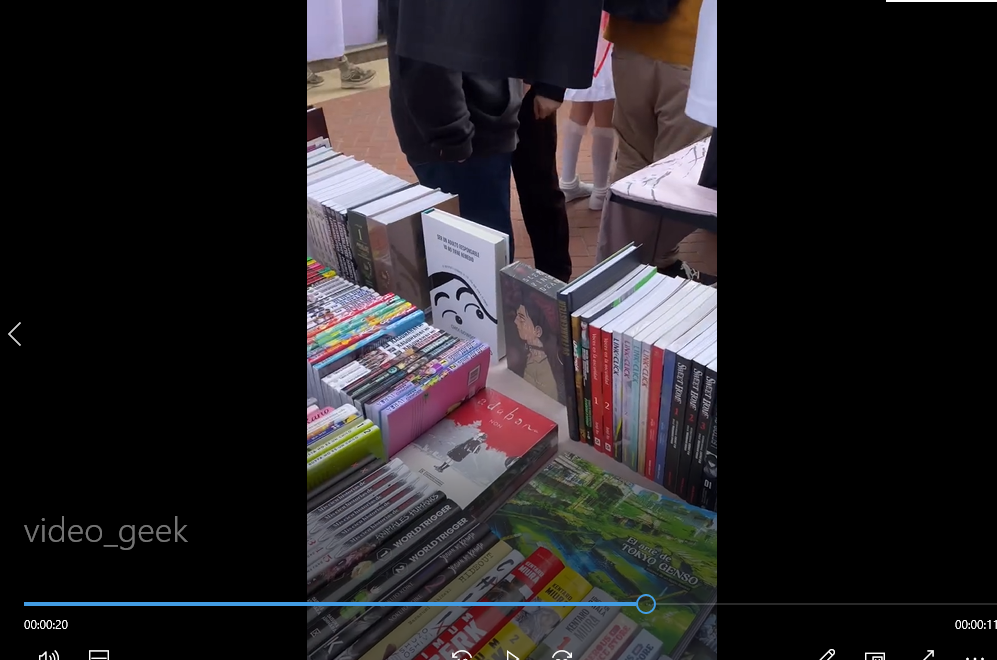

### Imagen de video output

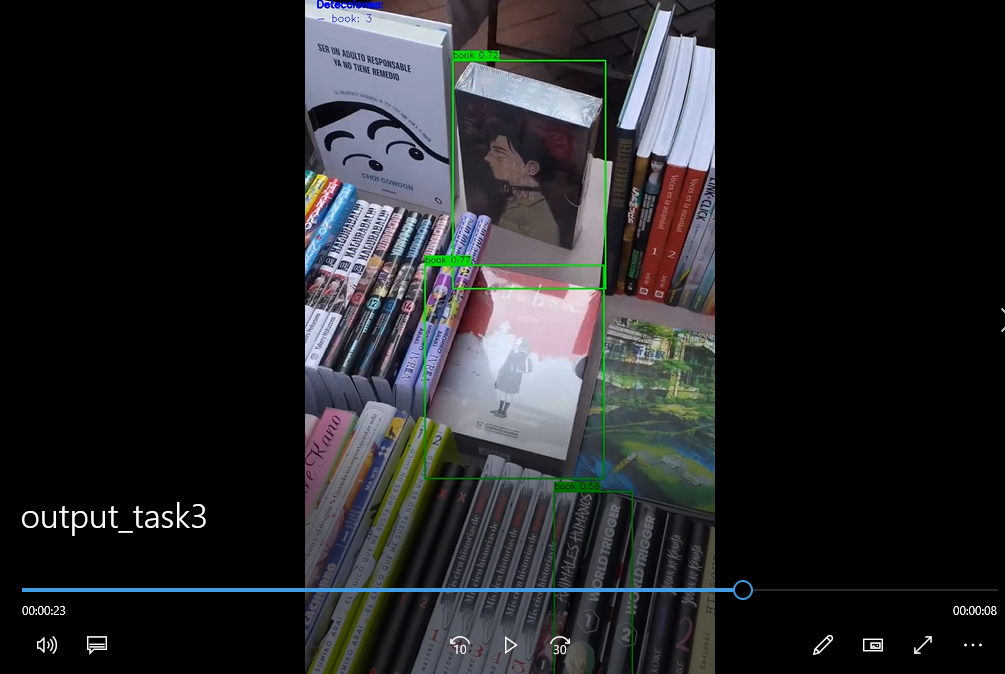